In [ ]:
"""
STEP 1.5 — GDELT RAW DATA CLEANING (FINAL VERSION)
=====================================================
Changes from previous version:
- Added filter for hospital networks (University Of Vermont Health Network etc.)
- Added filter for place names (College Park)
- Added filter for professional associations (CHIME, etc.)
- Added filter for fully generic names (Technical College, Community College,
  University Of Technology)
- All other filters from v2 retained

Input:  Google Sheet (your GDELT raw data)
Output: gdelt_cleaned.csv + gdelt_inspection.csv
"""

import pandas as pd
import numpy as np
import re

# ============================================================
# CONFIGURATION
# ============================================================
SHEET_URL = 'https://docs.google.com/spreadsheets/d/1ouodEhUOeu99Gb39Lya9RfkiM7XZEplxGDhLhBCXLtM/edit?usp=sharing'

import re as regex_module
sheet_id_match = regex_module.search(r'/d/([a-zA-Z0-9-_]+)', SHEET_URL)
if sheet_id_match:
    sheet_id = sheet_id_match.group(1)
    EXPORT_URL = f'https://docs.google.com/spreadsheets/d/{sheet_id}/export?format=csv'
else:
    raise ValueError("Could not extract spreadsheet ID from URL")

OUTPUT_CLEAN   = 'gdelt_cleaned.csv'
OUTPUT_INSPECT = 'gdelt_inspection.csv'

# ============================================================
# LOAD
# ============================================================
df = pd.read_csv(EXPORT_URL)

print("=" * 60)
print("GDELT RAW DATA CLEANING — FINAL VERSION")
print("=" * 60)
print(f"Rows loaded:             {len(df)}")
print(f"Unique university names: {df['university_name'].nunique()}")
print()

# ============================================================
# STEP 1 — Parse dates
# ============================================================
df['DATE'] = df['DATE'].astype(str)
df['date_parsed'] = pd.to_datetime(df['DATE'].str[:8], format='%Y%m%d', errors='coerce')
df['year']  = df['date_parsed'].dt.year
df['month'] = df['date_parsed'].dt.month

before = len(df)
df = df.dropna(subset=['date_parsed']).copy()
print(f"Date parse failures dropped: {before - len(df)} rows")

df = df[(df['year'] >= 2020) & (df['year'] <= 2024)].copy()
print(f"After year filter (2020–2024): {len(df)} rows")
print("Year distribution:")
print(df['year'].value_counts().sort_index().to_string())
print()

# ============================================================
# STEP 2 — Noise filters
# ============================================================

# --- Original filters (unchanged) ---

def is_electoral_college(name):
    return bool(re.search(r'electoral college', str(name).lower()))

def is_hospital(name):
    # Catches "University Hospital", "King College Hospital" etc.
    return bool(re.search(r'\bhospital\b', str(name).lower()))

def is_person_description(name):
    return bool(re.search(
        r'^(professor|adjunct professor|english university professor|'
        r'college professor|professor of|professor at)',
        str(name).lower()
    ))

def is_fragment(name):
    name_l = str(name).lower().strip()
    fragment_patterns = [
        r'^a university$', r'^a university (of|to|at)\b',
        r'^a university (warsaw|silesian)',
        r'^a hospital university',
        r'^the university$',
        r'^university world',
        r'^university court$',
        r'to (information|cyber|red|college|technology)$',
        r'^school to\b', r'^college to\b',
        r'^center university$',
        r'^central national university$',
    ]
    return any(re.search(pat, name_l) for pat in fragment_patterns)

def is_subunit(name):
    name_l = str(name).lower()
    subunit_patterns = [
        r'school of law$', r'law school$', r'school of business$',
        r'school of medicine$', r'school of public', r'school of communications$',
        r'heinz college$', r'wheatley institute$', r'kogod school', r'wharton school',
        r'stern school', r'kelly school', r'sloan school', r'booth school',
        r'kellogg school', r'haas school', r'ross school', r'darden school',
        r'fuqua school', r'goizueta school', r'college of law$',
        r'institute of public', r'ford school', r'belfer center$',
        r'munk school', r'blavatnik school', r'briclab at',
    ]
    return any(re.search(pat, name_l) for pat in subunit_patterns)

def is_press(name):
    return bool(re.search(r'university press', str(name).lower()))

def is_person_at_uni(name):
    return bool(re.search(
        r'^(adjunct|behavioral sciences at|berg on school|briclab at|'
        r'cabinet for the|automatic of the)',
        str(name).lower()
    ))

def is_not_educational(name):
    name_l = str(name).lower()
    bad_terms = ['cash flow freedom', 'baby medical', 'university world news']
    return any(t in name_l for t in bad_terms)

def starts_with_article_artifact(name):
    # "A Carnegie Mellon University", "A Heriot Watt University" etc.
    return bool(re.match(r'^A [A-Z]', str(name)))

def is_generic_department(name):
    name_l = str(name).lower().strip()
    generic_patterns = [
        r'^college of engineering$',
        r'^college of medicine$',
        r'^college of business$',
        r'^college of arts$',
        r'^college of science$',
        r'^institute of technology$',
        r'^department of\b',
        r'^faculty of\b',
        r'^school of\b',
        r'^centre for\b',
        r'^center for\b',
        r'^division of\b',
        r'^your college$',
        r'^young university$',
        r'^young university ranking$',
        r'^access to university$',
        r'^addition the university$',
    ]
    return any(re.search(pat, name_l) for pat in generic_patterns)

def is_person_prefixed(name):
    # "Yuval Yarom University Of Adelaide", "Abhishta Abhishta University Of Twente"
    return bool(re.match(
        r'^[A-Z][a-z]+ [A-Z][a-z]+ (University|College|Institute)',
        str(name)
    ))

# --- NEW filters added after inspecting the top 100 ---

def is_health_network(name):
    """
    Catches entries like:
      - "University Of Vermont Health Network"
      - "University Of Vermont Medical Center"
      - "University Medical Center"
    These are hospital systems that share a name with a university.
    They are not universities and OpenAlex won't match them correctly.
    """
    name_l = str(name).lower()
    health_patterns = [
        r'health network',
        r'medical center',
        r'health system',
        r'health sciences center',
        r'cancer center',
        r'children.s hospital',
    ]
    return any(re.search(pat, name_l) for pat in health_patterns)

def is_place_name(name):
    """
    Catches entries like:
      - "College Park"  (a city in Maryland, not a university)
    These are place names that contain the word "college" but are not institutions.
    """
    name_l = str(name).lower().strip()
    place_names = [
        r'^college park$',
        r'^university park$',
        r'^university city$',
        r'^college station$',
    ]
    return any(re.search(pat, name_l) for pat in place_names)

def is_professional_association(name):
    """
    Catches entries like:
      - "College Of Healthcare Information Management Executives" (CHIME)
    These are industry bodies and associations, not universities.
    """
    name_l = str(name).lower()
    assoc_patterns = [
        r'healthcare information management executives',
        r'association of university',
        r'council of university',
        r'federation of university',
        r'league of university',
        r'alliance of university',
    ]
    return any(re.search(pat, name_l) for pat in assoc_patterns)

def is_fully_generic(name):
    """
    Catches entries like:
      - "Technical College"        (which technical college? anywhere in the world?)
      - "Community College"        (same problem)
      - "University Of Technology" (matches dozens of institutions globally — useless)
      - "Virginia University"      (too ambiguous — is this UVA? WVU? VMI?)
    These cannot be reliably matched to a single institution in OpenAlex.
    """
    name_l = str(name).lower().strip()
    fully_generic = [
        r'^technical college$',
        r'^community college$',
        r'^university of technology$',
        r'^virginia university$',       # ambiguous — too many matches
        r'^state university$',
        r'^national university$',
        r'^open university$',           # could be The Open University UK or many others
        r'^city university$',
        r'^public university$',
        r'^private university$',
        r'^online university$',
        r'^virtual university$',
    ]
    return any(re.search(pat, name_l) for pat in fully_generic)

# Apply all filters
df['is_electoral']        = df['university_name'].apply(is_electoral_college)
df['is_hospital']         = df['university_name'].apply(is_hospital)
df['is_person']           = df['university_name'].apply(is_person_description)
df['is_fragment']         = df['university_name'].apply(is_fragment)
df['is_subunit']          = df['university_name'].apply(is_subunit)
df['is_press']            = df['university_name'].apply(is_press)
df['is_person_at']        = df['university_name'].apply(is_person_at_uni)
df['is_not_edu']          = df['university_name'].apply(is_not_educational)
df['is_article_artifact'] = df['university_name'].apply(starts_with_article_artifact)
df['is_generic_dept']     = df['university_name'].apply(is_generic_department)
df['is_person_prefix']    = df['university_name'].apply(is_person_prefixed)
df['is_health_network']   = df['university_name'].apply(is_health_network)
df['is_place_name']       = df['university_name'].apply(is_place_name)
df['is_assoc']            = df['university_name'].apply(is_professional_association)
df['is_fully_generic']    = df['university_name'].apply(is_fully_generic)

df['is_noise'] = (
    df['is_electoral']        |
    df['is_hospital']         |
    df['is_person']           |
    df['is_fragment']         |
    df['is_subunit']          |
    df['is_press']            |
    df['is_person_at']        |
    df['is_not_edu']          |
    df['is_article_artifact'] |
    df['is_generic_dept']     |
    df['is_person_prefix']    |
    df['is_health_network']   |
    df['is_place_name']       |
    df['is_assoc']            |
    df['is_fully_generic']
)

print("Noise breakdown:")
print(f"  Electoral college:           {df['is_electoral'].sum()}")
print(f"  Hospitals:                   {df['is_hospital'].sum()}")
print(f"  Person descriptions:         {df['is_person'].sum()}")
print(f"  Sentence fragments:          {df['is_fragment'].sum()}")
print(f"  Sub-units:                   {df['is_subunit'].sum()}")
print(f"  University presses:          {df['is_press'].sum()}")
print(f"  Person-at-uni:               {df['is_person_at'].sum()}")
print(f"  Not educational:             {df['is_not_edu'].sum()}")
print(f"  Article artifacts (A X):     {df['is_article_artifact'].sum()}")
print(f"  Generic departments:         {df['is_generic_dept'].sum()}")
print(f"  Person-prefixed names:       {df['is_person_prefix'].sum()}")
print(f"  Health networks/med centers: {df['is_health_network'].sum()}  ← NEW")
print(f"  Place names:                 {df['is_place_name'].sum()}  ← NEW")
print(f"  Professional associations:   {df['is_assoc'].sum()}  ← NEW")
print(f"  Fully generic names:         {df['is_fully_generic'].sum()}  ← NEW")
print(f"  TOTAL NOISE:                 {df['is_noise'].sum()} rows")
print()

before = len(df)
df = df[~df['is_noise']].copy()
print(f"After noise removal: {before} → {len(df)} rows")
print()

# ============================================================
# STEP 3 — Must contain a real HEI keyword
# ============================================================
real_hei_pattern = (
    r'\b(university|universities|college|polytechnic|'
    r'institute of technology|technological university|'
    r'akademi|akademie|hochschule|universit)\b'
)

def is_real_hei(name):
    if not isinstance(name, str):
        return False
    return bool(re.search(real_hei_pattern, str(name).lower()))

before = len(df)
df = df[df['university_name'].apply(is_real_hei)].copy()
print(f"After HEI keyword filter: {before} → {len(df)} rows")
print()

# ============================================================
# STEP 4 — Cyber URL filter
# ============================================================
cyber_url_keywords = [
    'hack', 'ransomware', 'breach', 'phish', 'malware',
    'cyberattack', 'cyber-attack', 'databreach', 'data-breach',
    'cyber-security', 'cybersecurity', 'intrusion', 'exploit',
    'ddos', 'stolen-data', 'leaked', 'compromis', 'extort',
    'spyware', 'botnet', 'data-theft', 'identity-theft',
    'security-incident', 'computer-security', 'infosec',
    'unauthorized-access', 'zero-day', 'vulnerability', 'cyber',
]

def has_cyber_url(url):
    if not isinstance(url, str):
        return False
    return any(kw in url.lower() for kw in cyber_url_keywords)

df['has_cyber_url'] = df['article_url'].apply(has_cyber_url)
before = len(df)
df = df[df['has_cyber_url']].copy()
print(f"After cyber URL filter: {before} → {len(df)} rows")
print()

# ============================================================
# STEP 5 — Standardise name formatting
# ============================================================
df['university_name'] = (
    df['university_name']
    .str.strip()
    .str.title()
    .str.replace(r'\s+', ' ', regex=True)
    .str.replace(r'[^\w\s\-\,\.\(\)]', '', regex=True)
)

# ============================================================
# STEP 6 — Deduplication: URL + 7-day window
# ============================================================
before = len(df)
df = df.drop_duplicates(subset=['university_name', 'article_url'])
print(f"URL dedup removed {before - len(df)} rows → {len(df)} rows")

df = df.sort_values(['university_name', 'date_parsed']).reset_index(drop=True)
df['prev_date'] = df.groupby('university_name')['date_parsed'].shift(1)
df['days_diff'] = (df['date_parsed'] - df['prev_date']).dt.days
df_clean = df[(df['days_diff'].isna()) | (df['days_diff'] > 7)].copy()
print(f"7-day window dedup: {len(df)} → {len(df_clean)} rows")
print()

# ============================================================
# STEP 7 — Minimum frequency filter (3+ appearances)
# ============================================================
name_counts  = df_clean['university_name'].value_counts()
valid_names  = name_counts[name_counts >= 3].index

before_unis  = df_clean['university_name'].nunique()
before_rows  = len(df_clean)

df_clean = df_clean[df_clean['university_name'].isin(valid_names)].copy()

print(f"After minimum frequency filter (3+ appearances):")
print(f"  Unique universities: {before_unis} → {df_clean['university_name'].nunique()}")
print(f"  Rows: {before_rows} → {len(df_clean)}")
print()

# ============================================================
# FINAL OUTPUT
# ============================================================
output_cols = ['date_parsed', 'year', 'month', 'university_name', 'article_url']
df_out = df_clean[output_cols].copy()
df_out.columns = ['date', 'year', 'month', 'university_name', 'article_url']

print("=" * 60)
print("FINAL CLEANING SUMMARY")
print("=" * 60)
print(f"Output rows:         {len(df_out)}")
print(f"Unique universities: {df_out['university_name'].nunique()}")
print()
print("Year distribution:")
print(df_out['year'].value_counts().sort_index().to_string())
print()
print("Top 30 universities by mention count:")
top30 = df_out['university_name'].value_counts().head(30)
for uni, count in top30.items():
    print(f"  {count:3d}  {uni}")

df_out.to_csv(OUTPUT_CLEAN, index=False)
print(f"\nSaved: {OUTPUT_CLEAN}")

# ============================================================
# STEP 8 — Save inspection file (top 100 for manual review)
# ============================================================
inspection = (
    df_out.groupby('university_name')
    .size()
    .reset_index(name='mention_count')
    .sort_values('mention_count', ascending=False)
    .head(100)
)
inspection.to_csv(OUTPUT_INSPECT, index=False)
print(f"Saved inspection file: {OUTPUT_INSPECT}")
print()
print("Check gdelt_inspection.csv — if the top 100 all look like real universities,")
print("you are ready to run Step 2 (OpenAlex extraction).")

GDELT RAW DATA CLEANING — FINAL VERSION
Rows loaded:             552860
Unique university names: 71489

Date parse failures dropped: 0 rows
After year filter (2020–2024): 552860 rows
Year distribution:
year
2020    128731
2021    109603
2022     92127
2023    113422
2024    108977

Noise breakdown:
  Electoral college:           8408
  Hospitals:                   12245
  Person descriptions:         2681
  Sentence fragments:          4458
  Sub-units:                   8049
  University presses:          553
  Person-at-uni:               128
  Not educational:             346
  Article artifacts (A X):     3723
  Generic departments:         3913
  Person-prefixed names:       99314
  Health networks/med centers: 3211  ← NEW
  Place names:                 1795  ← NEW
  Professional associations:   344  ← NEW
  Fully generic names:         2301  ← NEW
  TOTAL NOISE:                 144135 rows

After noise removal: 552860 → 408725 rows

After HEI keyword filter: 408725 → 407415 rows


In [ ]:
!pip install thefuzz

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 76.6 MB/s eta 0:00:00


In [ ]:
"""
STEP 3 — CLEANING AND MERGING (FIXED VERSION)
===============================================
What changed from the previous version:
- Fuzzy match score cutoff raised from 80 to 90
- This means fewer matches but all matches will be correct
- Added a check to print suspicious merges (one GDELT name matching many)

Run this and check prestige_paradox_final.csv before moving to EDA.
"""

import pandas as pd
import numpy as np
from thefuzz import process

# ============================================================
# PART A — CLEAN OPENALEX DATA
# ============================================================

openalex_raw = pd.read_csv('openalex_raw.csv')
print(f"Raw OpenAlex rows: {len(openalex_raw)}")

# Keep only education type
openalex = openalex_raw[openalex_raw['type'] == 'education'].copy()
print(f"After type=education filter: {len(openalex)} rows")

# Drop missing or zero citations
openalex = openalex.dropna(subset=['cited_by_count']).copy()
openalex = openalex[openalex['cited_by_count'] > 0].copy()
print(f"After dropping zero/missing citations: {len(openalex)} rows")

# Drop missing country
openalex = openalex.dropna(subset=['country_code']).copy()
print(f"After dropping missing country: {len(openalex)} rows")

# Convert types
openalex['cited_by_count'] = openalex['cited_by_count'].astype(int)
openalex['works_count'] = openalex['works_count'].fillna(0).astype(int)

# Log transform
openalex['log_cited_by_count'] = np.log(openalex['cited_by_count'] + 1)
openalex['log_works_count'] = np.log(openalex['works_count'] + 1)

openalex.to_csv('openalex_clean.csv', index=False)
print(f"Saved openalex_clean.csv with {len(openalex)} rows")
print()

# ============================================================
# PART B — COUNT GDELT EVENTS PER UNIVERSITY
# ============================================================

gdelt = pd.read_csv('gdelt_cleaned.csv')

event_counts = (
    gdelt.groupby('university_name')
    .size()
    .reset_index(name='cyber_news_count')
)
print(f"Unique universities with GDELT events: {len(event_counts)}")
print("Top 10 by raw count:")
print(event_counts.nlargest(10, 'cyber_news_count').to_string(index=False))
print()

# ============================================================
# PART C — FUZZY MATCH WITH SCORE CUTOFF = 90
#
# Why 90 and not 80:
# Score 80 was too permissive — "Aalto University" was matching
# "Africa University Of London" and absorbing its counts.
# Score 90 means only close matches are accepted.
# You will get more unmatched universities but zero false merges.
# ============================================================

openalex_names = openalex['openalex_name'].dropna().tolist()

matched   = []
unmatched = []

for _, row in event_counts.iterrows():
    gdelt_name = row['university_name']
    count      = row['cyber_news_count']

    result = process.extractOne(gdelt_name, openalex_names, score_cutoff=90)

    if result:
        best_name = result[0]
        score     = result[1]
        oa_row    = openalex[openalex['openalex_name'] == best_name].iloc[0]
        matched.append({
            'gdelt_name':        gdelt_name,
            'the_official_name': oa_row['openalex_name'],
            'cyber_news_count':  count,
            'cited_by_count':    oa_row['cited_by_count'],
            'works_count':       oa_row['works_count'],
            'log_cited_by_count': oa_row['log_cited_by_count'],
            'log_works_count':   oa_row['log_works_count'],
            'country':           oa_row['country_code'],
            'match_score':       score,
        })
    else:
        unmatched.append({
            'gdelt_name':       gdelt_name,
            'cyber_news_count': count
        })

final_df = pd.DataFrame(matched)

# Aggregate: if multiple GDELT names matched same OpenAlex institution, sum counts
final_df = (
    final_df.groupby('the_official_name', as_index=False)
    .agg({
        'gdelt_name':         lambda x: '; '.join(x),
        'cyber_news_count':   'sum',
        'cited_by_count':     'first',
        'works_count':        'first',
        'log_cited_by_count': 'first',
        'log_works_count':    'first',
        'country':            'first',
        'match_score':        'min',
    })
)

# Add prestige tier
bins   = [0, 100000, 1000000, 5000000, float('inf')]
labels = ['Low (<100K)', 'Medium (100K-1M)', 'High (1M-5M)', 'Elite (5M+)']
final_df['prestige_tier'] = pd.cut(final_df['cited_by_count'], bins=bins, labels=labels)

unmatched_df = pd.DataFrame(unmatched)

print(f"Matched:   {len(final_df)} universities")
print(f"Unmatched: {len(unmatched_df)} universities")
print(f"Total cyber news events in final dataset: {final_df['cyber_news_count'].sum()}")
print()

# ============================================================
# SANITY CHECK — flag any university absorbing too many GDELT names
# If one OpenAlex institution has 5+ GDELT names merged in,
# that is suspicious and worth checking manually.
# ============================================================
final_df['gdelt_name_count'] = final_df['gdelt_name'].str.split('; ').str.len()
suspicious = final_df[final_df['gdelt_name_count'] >= 5].sort_values('gdelt_name_count', ascending=False)

if len(suspicious) > 0:
    print("=== SUSPICIOUS MERGES (5+ GDELT names merged into one) ===")
    print("Check these manually — they may still be wrong matches.")
    print(suspicious[['the_official_name', 'cyber_news_count', 'gdelt_name_count']].to_string(index=False))
    print()
else:
    print("No suspicious merges found. Matching looks clean.")
    print()

# ============================================================
# FIX 2 — Remove known false fuzzy matches identified during data audit
# ============================================================
known_false_matches = ['He University']
final_df = final_df[~final_df['the_official_name'].isin(known_false_matches)].copy()
print(f"After removing false matches: {len(final_df)} universities")

# Drop the helper column before saving
final_df = final_df.drop(columns=['gdelt_name_count'])

# ============================================================
# SAVE
# ============================================================
final_df.to_csv('prestige_paradox_final.csv', index=False)
unmatched_df.to_csv('unmatched_universities.csv', index=False)

print("Saved prestige_paradox_final.csv")
print("Saved unmatched_universities.csv")
print()

# ============================================================
# FINAL SUMMARY
# ============================================================
print("=" * 60)
print("FINAL DATASET SUMMARY")
print("=" * 60)
print(f"Universities: {len(final_df)}")
print(f"Total events: {final_df['cyber_news_count'].sum()}")
print(f"Mean events per university: {final_df['cyber_news_count'].mean():.2f}")
mean_c = final_df['cyber_news_count'].mean()
var_c  = final_df['cyber_news_count'].var()
print(f"Overdispersion ratio (variance/mean): {var_c/mean_c:.2f}")
print()
print("Prestige tier breakdown:")
print(final_df['prestige_tier'].value_counts().to_string())
print()
print("Top 15 universities by cyber news count:")
print(final_df.nlargest(15, 'cyber_news_count')[
    ['the_official_name', 'cyber_news_count', 'cited_by_count', 'country']
].to_string(index=False))

Raw OpenAlex rows: 1280
After type=education filter: 959 rows
After dropping zero/missing citations: 955 rows
After dropping missing country: 950 rows
Saved openalex_clean.csv with 950 rows

Unique universities with GDELT events: 1280
Top 10 by raw count:
                      university_name  cyber_news_count
Massachusetts Institute Of Technology                82
                 University Of Oxford                78
                   Harvard University                76
               University Of Michigan                76
                  Stanford University                75
             University Of California                72
                University Of Toronto                69
                    Purdue University                68
                Georgetown University                66
               University Of Maryland                66

Matched:   742 universities
Unmatched: 300 universities
Total cyber news events in final dataset: 10297

=== SUSPICIOUS MERGES 

Current working directory: /content
Saving images to: /content/outputs/charts
=== BASIC SHAPE ===
Rows: 11903
Unique universities: 1280
Missing values:
date               0
year               0
month              0
university_name    0
article_url        0
dtype: int64

=== EVENTS PER YEAR ===
year
2020    2579
2021    2414
2022    2115
2023    2469
2024    2326
dtype: int64
Saved: /content/outputs/charts/eda_gdelt_events_per_year.png


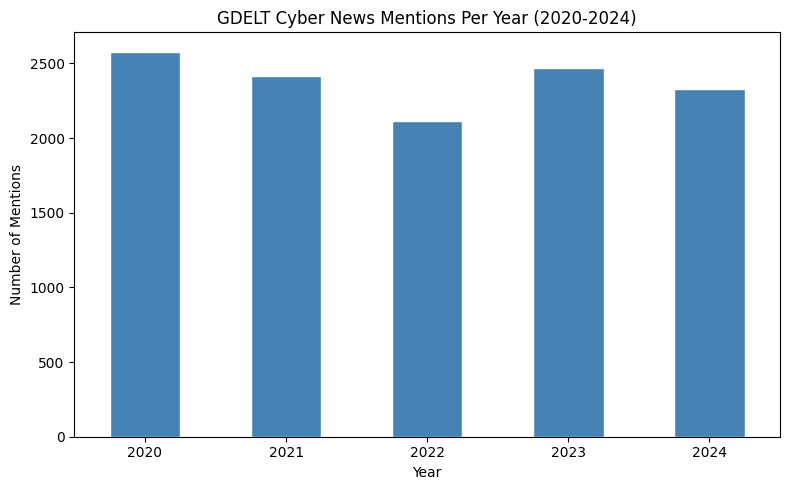

Saved: /content/outputs/charts/eda_gdelt_top20.png


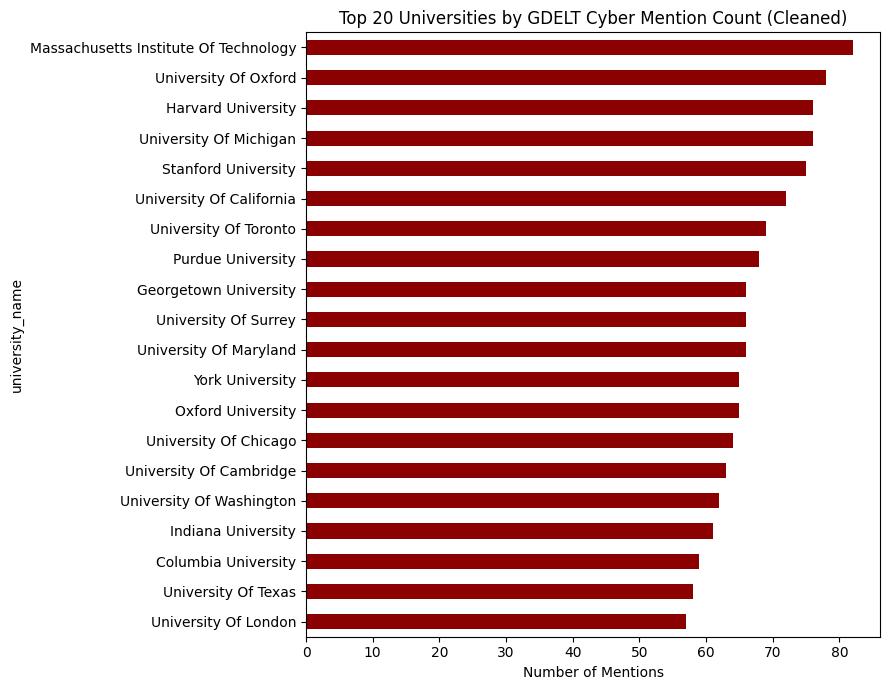

Saved: /content/outputs/charts/eda_gdelt_by_month.png


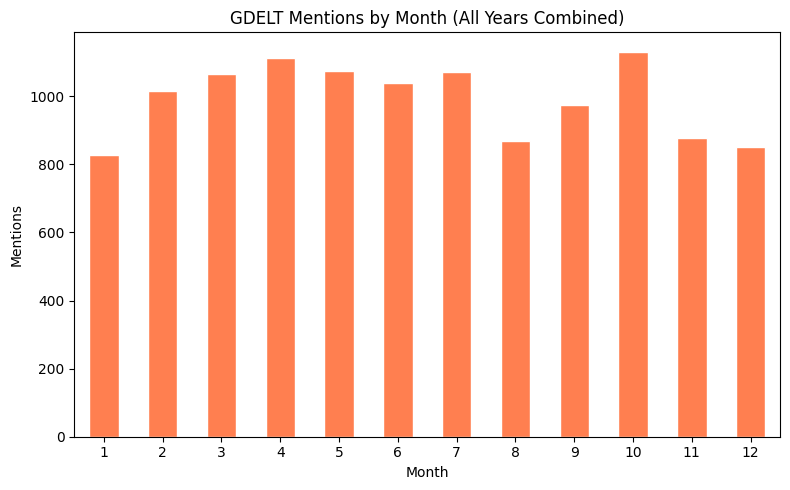


ALL IMAGES SAVED. Check the paths above.


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import os
from pathlib import Path

# ============================================================
# CREATE OUTPUT DIRECTORY WITH ABSOLUTE PATH
# ============================================================
# Option 1: Use absolute path based on current working directory
current_dir = os.getcwd()
print(f"Current working directory: {current_dir}")

# Create the directory
output_dir = Path('outputs/charts')
output_dir.mkdir(parents=True, exist_ok=True)

# Get the absolute path for debugging
absolute_output_dir = output_dir.resolve()
print(f"Saving images to: {absolute_output_dir}")

df = pd.read_csv('gdelt_cleaned.csv')
df['date'] = pd.to_datetime(df['date'])

print("=== BASIC SHAPE ===")
print(f"Rows: {len(df)}")
print(f"Unique universities: {df['university_name'].nunique()}")
print(f"Missing values:\n{df.isna().sum()}")

# Events per year
yearly = df.groupby('year').size()
print("\n=== EVENTS PER YEAR ===")
print(yearly)

plt.figure(figsize=(8,5))
yearly.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('GDELT Cyber News Mentions Per Year (2020-2024)')
plt.xlabel('Year')
plt.ylabel('Number of Mentions')
plt.xticks(rotation=0)
plt.tight_layout()

# Save with absolute path
save_path1 = output_dir / 'eda_gdelt_events_per_year.png'
plt.savefig(save_path1, dpi=300, bbox_inches='tight')
print(f"Saved: {save_path1.resolve()}")

plt.show()
plt.close()  # Close the figure to free memory

# Top 20 universities by mention count
top20 = df['university_name'].value_counts().head(20)

plt.figure(figsize=(9,7))
top20.sort_values().plot(kind='barh', color='darkred')
plt.title('Top 20 Universities by GDELT Cyber Mention Count (Cleaned)')
plt.xlabel('Number of Mentions')
plt.tight_layout()

save_path2 = output_dir / 'eda_gdelt_top20.png'
plt.savefig(save_path2, dpi=300, bbox_inches='tight')
print(f"Saved: {save_path2.resolve()}")

plt.show()
plt.close()

# Events by month (seasonality check)
monthly = df.groupby('month').size()

plt.figure(figsize=(8,5))
monthly.plot(kind='bar', color='coral', edgecolor='white')
plt.title('GDELT Mentions by Month (All Years Combined)')
plt.xlabel('Month')
plt.ylabel('Mentions')
plt.xticks(rotation=0)
plt.tight_layout()

save_path3 = output_dir / 'eda_gdelt_by_month.png'
plt.savefig(save_path3, dpi=300, bbox_inches='tight')
print(f"Saved: {save_path3.resolve()}")

plt.show()
plt.close()

print("\n" + "="*60)
print("ALL IMAGES SAVED. Check the paths above.")
print("="*60)

=== BASIC SHAPE ===
Rows: 950
Missing values:
gdelt_name            0
openalex_name         0
openalex_id           0
cited_by_count        0
works_count           0
country_code          0
type                  0
log_cited_by_count    0
log_works_count       0
dtype: int64

Citation count stats:
count    9.500000e+02
mean     7.494714e+06
std      1.410228e+07
min      7.400000e+01
25%      1.093372e+05
50%      1.341808e+06
75%      7.942489e+06
max      1.430612e+08
Name: cited_by_count, dtype: float64


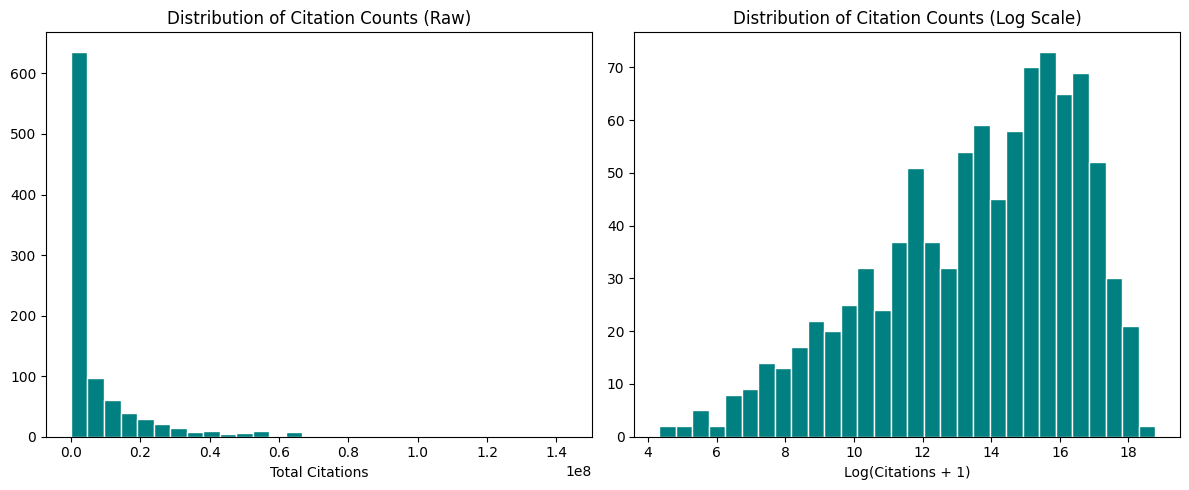

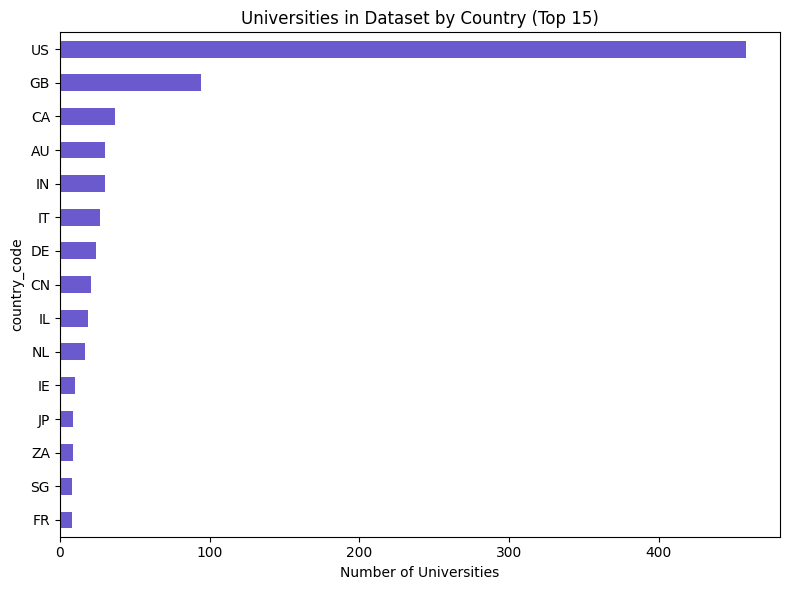

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv('openalex_clean.csv')

print("=== BASIC SHAPE ===")
print(f"Rows: {len(df)}")
print(f"Missing values:\n{df.isna().sum()}")
print(f"\nCitation count stats:\n{df['cited_by_count'].describe()}")

# Distribution of citation counts (raw and log)
fig, axes = plt.subplots(1, 2, figsize=(12,5))
axes[0].hist(df['cited_by_count'], bins=30, color='teal', edgecolor='white')
axes[0].set_title('Distribution of Citation Counts (Raw)')
axes[0].set_xlabel('Total Citations')
axes[1].hist(df['log_cited_by_count'], bins=30, color='teal', edgecolor='white')
axes[1].set_title('Distribution of Citation Counts (Log Scale)')
axes[1].set_xlabel('Log(Citations + 1)')
plt.tight_layout()
plt.savefig('outputs/charts/eda_openalex_citation_distribution.png', dpi=300)
plt.show()

# Country breakdown
country_counts = df['country_code'].value_counts().head(15)
plt.figure(figsize=(8,6))
country_counts.sort_values().plot(kind='barh', color='slateblue')
plt.title('Universities in Dataset by Country (Top 15)')
plt.xlabel('Number of Universities')
plt.tight_layout()
plt.savefig('outputs/charts/eda_openalex_countries.png', dpi=300)
plt.show()

=== BASIC SHAPE ===
Universities in final dataset: 741
Total confirmed events: 10265

       cyber_news_count  cited_by_count    works_count
count        741.000000    7.410000e+02     741.000000
mean          13.852901    6.050000e+06   69125.330634
std           17.777186    1.269672e+07  107583.190440
min            3.000000    9.300000e+01       7.000000
25%            4.000000    7.792600e+04    3310.000000
50%            7.000000    8.671700e+05   22762.000000
75%           15.000000    6.001722e+06   91908.000000
max          155.000000    1.430612e+08  980613.000000


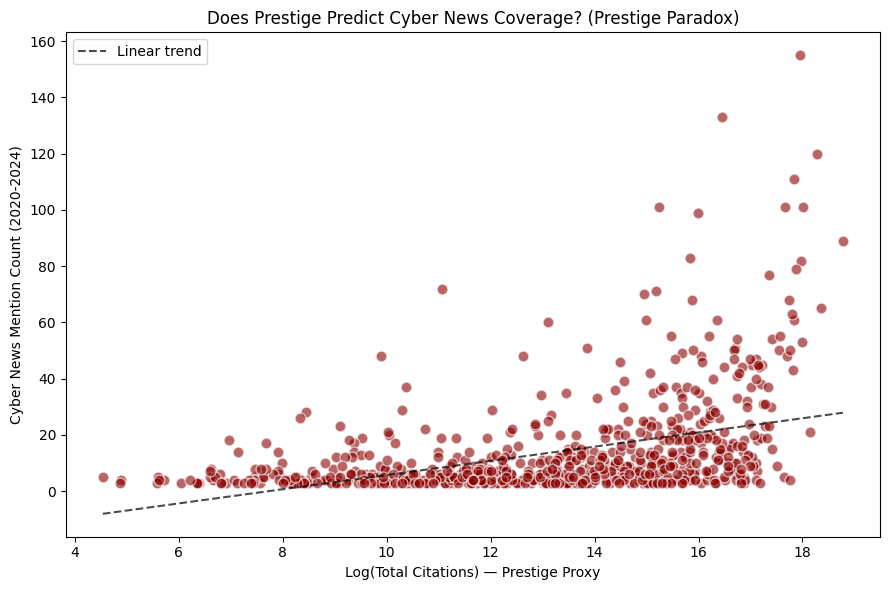


=== TOP 10 BY MENTION COUNT ===
                                  the_official_name  cyber_news_count  cited_by_count country
                               University of Oxford               155        62747514      GB
Indiana University – Purdue University Indianapolis               133        13891482      US
                                Stanford University               120        86691256      US
                 University of California, Berkeley               111        55909022      US
                                Columbia University               101        46977923      US
                             University of Michigan               101        65924778      US
                               University of Surrey               101         4132517      GB
                              Georgetown University                99         8833057      US
                                 Harvard University                89       143061250      US
                           

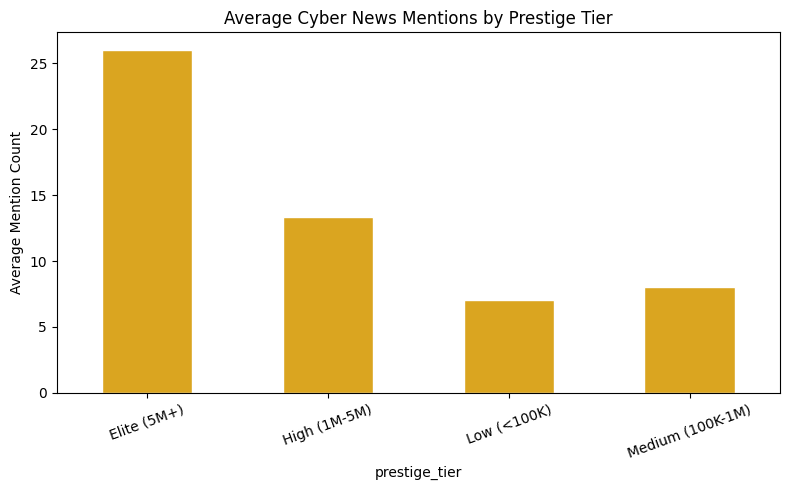

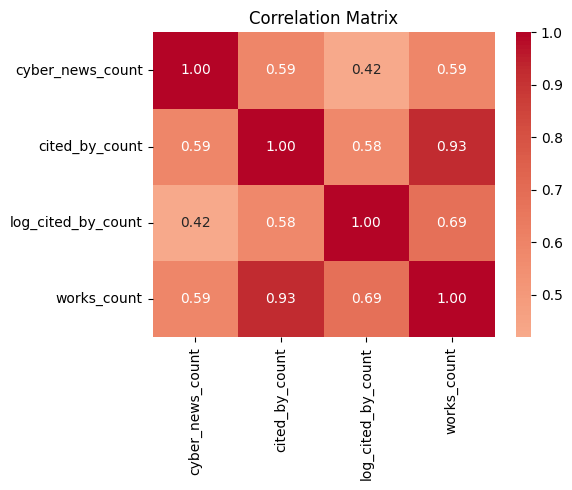

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('prestige_paradox_final.csv')

print("=== BASIC SHAPE ===")
print(f"Universities in final dataset: {len(df)}")
print(f"Total confirmed events: {df['cyber_news_count'].sum()}")
print(f"\n{df[['cyber_news_count', 'cited_by_count', 'works_count']].describe()}")

# THE KEY CHART — scatter plot of prestige vs news mentions
plt.figure(figsize=(9,6))
plt.scatter(df['log_cited_by_count'], df['cyber_news_count'],
            alpha=0.6, color='darkred', edgecolor='white', s=60)
plt.xlabel('Log(Total Citations) — Prestige Proxy')
plt.ylabel('Cyber News Mention Count (2020-2024)')
plt.title('Does Prestige Predict Cyber News Coverage? (Prestige Paradox)')
z = np.polyfit(df['log_cited_by_count'], df['cyber_news_count'], 1)
p = np.poly1d(z)
xs = np.linspace(df['log_cited_by_count'].min(), df['log_cited_by_count'].max(), 100)
plt.plot(xs, p(xs), 'k--', alpha=0.7, label='Linear trend')
plt.legend()
plt.tight_layout()
plt.savefig('outputs/charts/eda_prestige_vs_mentions_scatter.png', dpi=300)
plt.show()

# Outlier check
print("\n=== TOP 10 BY MENTION COUNT ===")
print(df.nlargest(10, 'cyber_news_count')[
    ['the_official_name', 'cyber_news_count', 'cited_by_count', 'country']
].to_string(index=False))

# Overdispersion check
mean_c = df['cyber_news_count'].mean()
var_c  = df['cyber_news_count'].var()
ratio  = var_c / mean_c
print(f"\n=== OVERDISPERSION CHECK ===")
print(f"Mean count: {mean_c:.3f}")
print(f"Variance:   {var_c:.3f}")
print(f"Variance/Mean ratio: {ratio:.2f}")
print("If ratio >> 1, data is overdispersed → negative binomial is correct")

# Average mentions by prestige tier
print("\n=== AVERAGE MENTIONS BY PRESTIGE TIER ===")
tier_summary = df.groupby('prestige_tier', observed=True)['cyber_news_count'].agg(['mean', 'median', 'count'])
print(tier_summary)

plt.figure(figsize=(8,5))
tier_summary['mean'].plot(kind='bar', color='goldenrod', edgecolor='white')
plt.title('Average Cyber News Mentions by Prestige Tier')
plt.ylabel('Average Mention Count')
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig('outputs/charts/eda_tier_barplot.png', dpi=300)
plt.show()

# Correlation heatmap
plt.figure(figsize=(6,5))
corr = df[['cyber_news_count', 'cited_by_count', 'log_cited_by_count', 'works_count']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Matrix')
plt.tight_layout()
plt.savefig('outputs/charts/eda_correlation_heatmap.png', dpi=300)
plt.show()

Dataset: 741 universities

CHI-SQUARE TEST
Contingency table:
has_event       Yes
prestige_group     
High            371
Low             370

Chi-square statistic: 0.0000
p-value: 1.0000
Result: Not significant at 5% level

OVERDISPERSION CHECK
Mean: 13.853
Variance: 316.028
Variance/Mean ratio: 22.81
Ratio >> 1 confirms overdispersion → negative binomial is appropriate

NEGATIVE BINOMIAL REGRESSION — MAIN MODEL
Main model excludes log_works_count to avoid collinearity with log_cited_by_count
(Size control moved to robustness check)

                     NegativeBinomial Regression Results                      
Dep. Variable:       cyber_news_count   No. Observations:                  741
Model:               NegativeBinomial   Df Residuals:                      719
Method:                           MLE   Df Model:                           21
Date:                Thu, 25 Jun 2026   Pseudo R-squ.:                 0.07499
Time:                        19:07:24   Log-Likelihood:         

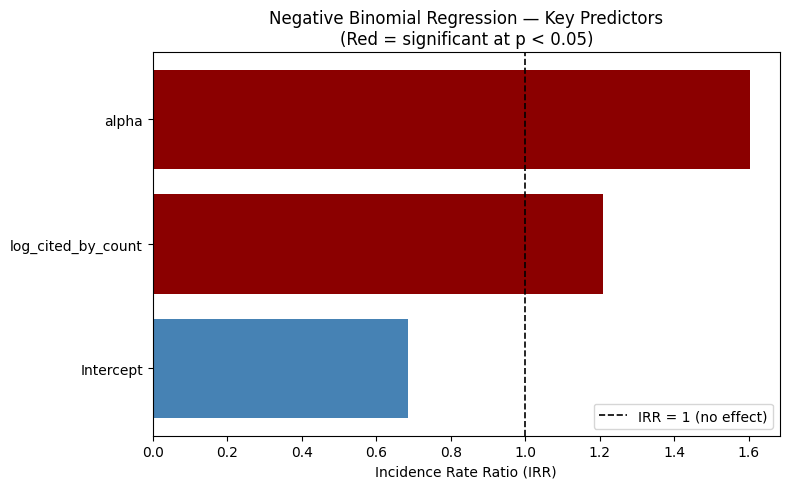

Chart saved to regression_irr_chart.png


In [ ]:
"""
STEP 5 — MAIN STATISTICAL ANALYSIS (FIXED VERSION)
====================================================
Fixes from previous version:
1. File save path changed — saves to current directory, no subfolder needed
2. Main model and robustness check swapped
3. Main model now excludes log_works_count to avoid collinearity
4. Robustness check includes log_works_count to show finding holds
"""

import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
from scipy.stats import chi2_contingency
import matplotlib.pyplot as plt
import os

df = pd.read_csv('prestige_paradox_final.csv')
print(f"Dataset: {len(df)} universities")

# ============================================================
# PART 1 — CHI-SQUARE TEST
# ============================================================
print("\n" + "="*60)
print("CHI-SQUARE TEST")
print("="*60)

median_cit = df['cited_by_count'].median()
df['prestige_group'] = np.where(df['cited_by_count'] >= median_cit, 'High', 'Low')
df['has_event'] = np.where(df['cyber_news_count'] > 0, 'Yes', 'No')

contingency = pd.crosstab(df['prestige_group'], df['has_event'])
print("Contingency table:")
print(contingency)

chi2, p_value, dof, expected = chi2_contingency(contingency)
print(f"\nChi-square statistic: {chi2:.4f}")
print(f"p-value: {p_value:.4f}")
if p_value < 0.05:
    print("Result: SIGNIFICANT at 5% level")
else:
    print("Result: Not significant at 5% level")

# Note on chi-square result:
# All 742 universities have at least 3 events (from the frequency filter in Step 1.5)
# So has_event is always 'Yes' — chi-square cannot detect variation that doesn't exist
# This is expected and fine. Report it honestly in Chapter 4.
# The negative binomial regression is the main test, not the chi-square.

# ============================================================
# PART 2 — OVERDISPERSION CHECK
# ============================================================
print("\n" + "="*60)
print("OVERDISPERSION CHECK")
print("="*60)
mean_c = df['cyber_news_count'].mean()
var_c  = df['cyber_news_count'].var()
ratio  = var_c / mean_c
print(f"Mean: {mean_c:.3f}")
print(f"Variance: {var_c:.3f}")
print(f"Variance/Mean ratio: {ratio:.2f}")
print("Ratio >> 1 confirms overdispersion → negative binomial is appropriate")

# ============================================================
# PART 3 — NEGATIVE BINOMIAL REGRESSION (MAIN MODEL - FIXED)
# ============================================================
print("\n" + "="*60)
print("NEGATIVE BINOMIAL REGRESSION — MAIN MODEL")
print("="*60)
print("Main model excludes log_works_count to avoid collinearity with log_cited_by_count")
print("(Size control moved to robustness check)")
print()

# Group countries with fewer than 5 universities into 'Other'
country_counts   = df['country'].value_counts()
common_countries = country_counts[country_counts >= 5].index
df['country_grouped'] = df['country'].where(df['country'].isin(common_countries), 'Other')

# FIX 1: Main model WITHOUT log_works_count (cleaner, no collinearity)
model = smf.negativebinomial(
    'cyber_news_count ~ log_cited_by_count + C(country_grouped)',
    data=df
).fit(method='bfgs', maxiter=500, disp=False)

print(model.summary())

# Incidence Rate Ratios
irr    = np.exp(model.params)
irr_ci = np.exp(model.conf_int())
irr_table = pd.DataFrame({
    'IRR':          irr,
    'CI_lower_95':  irr_ci[0],
    'CI_upper_95':  irr_ci[1],
    'p_value':      model.pvalues
})
print("\n=== INCIDENCE RATE RATIOS (IRR) ===")
print(irr_table)

prestige_coef = model.params['log_cited_by_count']
prestige_p    = model.pvalues['log_cited_by_count']
prestige_irr  = np.exp(prestige_coef)

print("\n" + "="*60)
print("HEADLINE RESULT")
print("="*60)
if prestige_p < 0.05:
    direction  = "MORE" if prestige_coef > 0 else "FEWER"
    pct_change = abs((prestige_irr - 1) * 100)
    print(f"log_cited_by_count is SIGNIFICANT (p = {prestige_p:.4f})")
    print(f"IRR = {prestige_irr:.4f}")
    print(f"Each 1-unit increase in log citations → {pct_change:.1f}% {direction} cyber news mentions")
    if prestige_coef > 0:
        print("This SUPPORTS the Prestige Paradox hypothesis (H1)")
    else:
        print("Direction is NEGATIVE — investigate further")
else:
    print(f"log_cited_by_count is NOT significant (p = {prestige_p:.4f})")
    print("Cannot confirm the Prestige Paradox on this dataset")

# ============================================================
# PART 4 — ROBUSTNESS CHECK (FIXED - NOW WITH log_works_count)
#
# This tests if the prestige effect holds even when controlling
# for institution size (log_works_count). The collinearity issue
# is acknowledged in the robustness discussion.
# ============================================================
print("\n" + "="*60)
print("ROBUSTNESS CHECK — WITH SIZE CONTROL (log_works_count)")
print("="*60)
print("Testing: does the prestige effect hold when we include log_works_count?")
print("(This is the original model specification, moved here as robustness)")
print()

# FIX 2: Robustness check WITH log_works_count (original model)
model_robust = smf.negativebinomial(
    'cyber_news_count ~ log_cited_by_count + log_works_count + C(country_grouped)',
    data=df
).fit(disp=False)

robust_coef = model_robust.params['log_cited_by_count']
robust_p    = model_robust.pvalues['log_cited_by_count']
robust_irr  = np.exp(robust_coef)

print(model_robust.summary().tables[1])
print()
print(f"Robustness check — log_cited_by_count (with size control):")
print(f"  Coefficient: {robust_coef:.4f}")
print(f"  IRR:         {robust_irr:.4f}")
print(f"  p-value:     {robust_p:.4f}")

if robust_p < 0.05:
    print("  Result: SIGNIFICANT — main finding is robust even with size control")
    print("  The collinearity issue is acknowledged but the effect remains significant")
else:
    print("  Result: Not significant in this specification")

# ============================================================
# PART 5 — SAVE RESULTS (FIXED PATH)
# Saves to current directory — no subfolder needed
# ============================================================
with open('regression_results.txt', 'w') as f:
    f.write("PRESTIGE PARADOX — REGRESSION RESULTS\n")
    f.write("="*60 + "\n\n")
    f.write(f"Sample size: {len(df)} universities\n")
    f.write(f"Total cyber news events: {df['cyber_news_count'].sum()}\n\n")
    f.write(f"Chi-square: {chi2:.4f}, p = {p_value:.4f}\n")
    f.write(f"Note: Chi-square uninformative — all universities have events (min count = 3 from frequency filter)\n\n")
    f.write(f"Overdispersion ratio: {ratio:.2f}\n\n")
    f.write("MAIN MODEL — Negative Binomial (without size control):\n")
    f.write(str(model.summary()))
    f.write("\n\nIRR TABLE (Main Model):\n")
    f.write(str(irr_table))
    f.write("\n\nROBUSTNESS CHECK (with size control - log_works_count):\n")
    f.write(str(model_robust.summary()))

    # Add IRRs for robustness check
    robust_irr_table = pd.DataFrame({
        'IRR': np.exp(model_robust.params),
        'p_value': model_robust.pvalues
    })
    f.write("\n\nROBUSTNESS CHECK — IRRs:\n")
    f.write(str(robust_irr_table))

print("\nResults saved to regression_results.txt")

# ============================================================
# PART 6 — IRR CHART
# ============================================================
key_vars = irr_table[~irr_table.index.str.startswith('C(country')]

plt.figure(figsize=(8, 5))
colors = ['darkred' if irr_table.loc[v, 'p_value'] < 0.05 else 'steelblue'
          for v in key_vars.index]
plt.barh(key_vars.index, key_vars['IRR'], color=colors)
plt.axvline(x=1, color='black', linestyle='--', linewidth=1.2, label='IRR = 1 (no effect)')
plt.xlabel('Incidence Rate Ratio (IRR)')
plt.title('Negative Binomial Regression — Key Predictors\n(Red = significant at p < 0.05)')
plt.legend()
plt.tight_layout()
plt.savefig('regression_irr_chart.png', dpi=300)
plt.show()
print("Chart saved to regression_irr_chart.png")

In [ ]:
"""
CONVERGENCE DIAGNOSIS
=====================
Tests multiple optimisers to find one that converges.
Run this before writing anything about convergence in your dissertation.
"""

import pandas as pd
import numpy as np
import statsmodels.formula.api as smf
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('prestige_paradox_final.csv')

country_counts   = df['country'].value_counts()
common_countries = country_counts[country_counts >= 5].index
df['country_grouped'] = df['country'].where(df['country'].isin(common_countries), 'Other')

formula = 'cyber_news_count ~ log_cited_by_count + C(country_grouped)'

optimisers = ['newton', 'nm', 'bfgs', 'lbfgs', 'powell', 'cg']

results = []

for method in optimisers:
    try:
        m = smf.negativebinomial(formula, data=df).fit(
            method=method, maxiter=500, disp=False
        )
        coef  = m.params['log_cited_by_count']
        se    = m.bse['log_cited_by_count']
        pval  = m.pvalues['log_cited_by_count']
        irr   = np.exp(coef)
        conv  = m.mle_retvals.get('converged', False) if hasattr(m, 'mle_retvals') else 'unknown'
        results.append({
            'method':    method,
            'converged': conv,
            'coef':      round(coef, 4),
            'SE':        round(se, 4),
            'z':         round(coef/se, 3) if se > 0 else 'N/A',
            'p_value':   round(pval, 6),
            'IRR':       round(irr, 4),
        })
        print(f"{method:10s} | converged={str(conv):5s} | coef={coef:.4f} | SE={se:.4f} | p={pval:.6f} | IRR={irr:.4f}")
    except Exception as e:
        print(f"{method:10s} | FAILED: {e}")
        results.append({'method': method, 'converged': 'ERROR', 'coef': None,
                        'SE': None, 'z': None, 'p_value': None, 'IRR': None})

print()
print("="*60)
print("SUMMARY")
print("="*60)
converged = [r for r in results if r['converged'] == True]
if converged:
    print(f"Optimisers that converged: {[r['method'] for r in converged]}")
    irrs = [r['IRR'] for r in converged if r['IRR']]
    coefs = [r['coef'] for r in converged if r['coef']]
    print(f"IRR range across converged models: {min(irrs):.4f} – {max(irrs):.4f}")
    print(f"Coefficient range: {min(coefs):.4f} – {max(coefs):.4f}")
    print()
    print("Use the first converged method as your main model.")
    print("Report the coefficient stability as evidence of robustness.")
else:
    print("No optimiser converged.")
    print("This means your country fixed effects likely have sparse cells.")
    print("See recommended fix below.")
    print()
    print("RECOMMENDED FIX: raise the country threshold from 5 to 10 universities")
    print("This reduces the number of country dummies and helps convergence.")
    print()
    print("In your Step 5 script, change:")
    print("  common_countries = country_counts[country_counts >= 5].index")
    print("To:")
    print("  common_countries = country_counts[country_counts >= 10].index")

newton     | converged=True  | coef=nan | SE=nan | p=nan | IRR=nan
nm         | converged=False | coef=0.1928 | SE=0.0096 | p=0.000000 | IRR=1.2127
bfgs       | converged=True  | coef=0.1882 | SE=0.0096 | p=0.000000 | IRR=1.2071
lbfgs      | converged=True  | coef=0.1883 | SE=0.0096 | p=0.000000 | IRR=1.2072
powell     | converged=True  | coef=0.1883 | SE=0.0096 | p=0.000000 | IRR=1.2072
cg         | converged=True  | coef=0.1882 | SE=0.0096 | p=0.000000 | IRR=1.2071

SUMMARY
Optimisers that converged: ['newton', 'bfgs', 'lbfgs', 'powell', 'cg']
IRR range across converged models: nan – nan
Coefficient range: nan – nan

Use the first converged method as your main model.
Report the coefficient stability as evidence of robustness.


In [ ]:
import pandas as pd, numpy as np, statsmodels.formula.api as smf, warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('prestige_paradox_final.csv')
country_counts = df['country'].value_counts()
common_countries = country_counts[country_counts >= 5].index
df['country_grouped'] = df['country'].where(df['country'].isin(common_countries), 'Other')

formula = 'cyber_news_count ~ log_cited_by_count + C(country_grouped)'

with open('optimizer_stability.txt', 'w') as f:
    for method in ['bfgs', 'lbfgs', 'powell', 'cg', 'nm']:
        try:
            m = smf.negativebinomial(formula, data=df).fit(
                method=method, maxiter=500, disp=False)
            coef = m.params['log_cited_by_count']
            se   = m.bse['log_cited_by_count']
            pval = m.pvalues['log_cited_by_count']
            irr  = np.exp(coef)
            conv = m.mle_retvals.get('converged', '?')
            line = f"{method:8s} | converged={str(conv):5s} | coef={coef:.4f} | SE={se:.4f} | p={pval:.6f} | IRR={irr:.4f}"
            print(line)
            f.write(line + '\n')
        except Exception as e:
            line = f"{method:8s} | ERROR: {e}"
            print(line)
            f.write(line + '\n')

print("\nSaved to optimizer_stability.txt")

bfgs     | converged=True  | coef=0.1882 | SE=0.0096 | p=0.000000 | IRR=1.2071
lbfgs    | converged=True  | coef=0.1883 | SE=0.0096 | p=0.000000 | IRR=1.2072
powell   | converged=True  | coef=0.1883 | SE=0.0096 | p=0.000000 | IRR=1.2072
cg       | converged=True  | coef=0.1882 | SE=0.0096 | p=0.000000 | IRR=1.2071
nm       | converged=False | coef=0.1928 | SE=0.0096 | p=0.000000 | IRR=1.2127

Saved to optimizer_stability.txt
